<a href="https://colab.research.google.com/github/louis-uwie/CSCI161-SocialComputing/blob/main/Binwag-FinalProject/CSCI161.03%20-%20BINWAG%2C%20Louis%20III%20-%20Data%20Analysis%20Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CSCI 161.03 - Introduction to Social Computing**

**Author:** BINWAG, Louis III G. (`github/louis-uwie`)

# **I. Introduction**

As part of the major requirement for **CSCI 161.03 - Introduction to Social Computing**, the author,

In `r/Philippines`, users tend to interact about on-going controversial issues in the Philippines. This ranges from the most recent `Nepo Babies` to rather old but still very relevant and recurring, `Agricultural Prices`.

**What I want to find out are:**

1. What are the common underlying themes in topics concerning **Agriculture?**
2. What **dominant emotions** emerge in these online conversations?
3. What are common indications?

# **II. About the Dataset**

 Please note that there is a great chance of including other social media platforms as well due to rate-limits of Reddit API Scraping.

Currently, there is `248 Rows`, and `8 Columns`.


| Column           | Definition                                      | Sample                                                              |
| ---------------- | ----------------------------------------------- | ------------------------------------------------------------------- |
| `post_title`     | Title of the Reddit post                        | *"Why is Python so popular in data science?"*                       |
| `post_url`       | Direct link to the Reddit post                  | `https://www.reddit.com/r/datascience/comments/abc123/...`          |
| `post_body`      | Main body text of the Reddit post (if provided) | *"I’ve noticed a lot of job postings require Python experience..."* |
| `post_author`    | Username of the Reddit post’s author            | `u/data_guru`                                                       |
| `post_score`     | Upvotes minus downvotes for the post            | `1542`                                                              |
| `comment`        | Text of the Reddit comment                      | *"Python has great libraries like pandas and scikit-learn."*        |
| `comment_author` | Username of the Reddit comment’s author         | `u/ml_enthusiast`                                                   |
| `comment_score`  | Upvotes minus downvotes for the comment         | `237`                                                               |



# **III. Data Collection**

Data collection will primarily utilize Reddit's PRAW (API) for datascraping. Connecting to Google drive for ease of use since the author will be using google collab for a more streamline and 'smoother' project.


In [1]:
!pip install praw

^C
ERROR: Operation cancelled by user


In [ ]:
# from dotenv import load_dotenv
# import os

# load_dotenv("/content/drive/CSCI 161/Project/redditdatascrape.env", override=True)

# CLIENT_ID = os.getenv("CLIENT_ID")
# CLIENT_SECRET = os.getenv("CLIENT_SECRET")

# print("CLIENT_ID:", CLIENT_ID)
# print("CLIENT_SECRET:", CLIENT_SECRET)


In [ ]:
import pandas as pd
import numpy as np
import nltk

import praw

import pandas as pd
from google.colab import drive
import datetime

import os

In [ ]:
reddit = praw.Reddit(
    client_id="390Mv4deA5sjduaY4-n2TA",
    client_secret="-lvWJJC94wvX8-7DLNrp0wgaa70EOA",
    user_agent="script:reddit_scraper:v1.0"
)

print("Read-only mode:", reddit.read_only)


Read-only mode: True


In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

subreddit = reddit.subreddit("Philippines")

posts_data = []

# Fetch more posts (adjust as needed)
for post in subreddit.search("Agriculture", limit=500):
    body = post.selftext if post.selftext else "[No text - maybe image/link post]"

    posts_data.append({
        "post_title": post.title,
        "post_url": "https://reddit.com" + post.permalink,
        "comment": None,
        "comment_author": None,
        "comment_score": None,
        "post_body": body,
        "post_score": post.score,
        "post_author": post.author.name if post.author else "[deleted]",
        "created_utc": pd.to_datetime(post.created_utc, unit="s")
    })

    # Fetch comments
    post.comments.replace_more(limit=0)
    for comment in post.comments.list():
        posts_data.append({
            "post_title": post.title,
            "post_url": "https://reddit.com" + post.permalink,
            "comment": comment.body,
            "comment_author": comment.author.name if comment.author else "[deleted]",
            "comment_score": comment.score,
            "post_body": None,
            "post_score": None,
            "post_author": None,
            "created_utc": pd.to_datetime(comment.created_utc, unit="s")
        })

# Save to Google Drive
df = pd.DataFrame(posts_data)

output_path = "/content/drive/MyDrive/reddit_truephilippines1000.csv"
df.to_csv(output_path, index=False)

print(f"Saved {len(df)} rows to {output_path}")


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/l

Saved 13244 rows to /content/drive/MyDrive/reddit_truephilippines1000.csv


In [ ]:
# from google.colab import drive
# import pandas as pd
# import time

# # Mount Google Drive
# drive.mount('/content/drive')

# subreddit = reddit.subreddit("truePhilippines")

# posts_data = []
# post_count = 0
# max_posts = 1000
# requests_made = 0
# start_time = time.time()

# for post in subreddit.hot(limit=None):
#     if post_count >= max_posts:
#         break

#     requests_made += 1
#     if requests_made >= 10:
#         elapsed = time.time() - start_time
#         if elapsed < 60:
#             sleep_time = 60 - elapsed
#             print(f"Sleeping {sleep_time:.1f} seconds to respect rate limits...")
#             time.sleep(sleep_time)

#         requests_made = 0
#         start_time = time.time()


#     body = post.selftext if post.selftext else "[No text - maybe image/link post]"
#     posts_data.append({
#         "post_title": post.title,
#         "post_url": "https://reddit.com" + post.permalink,
#         "comment": None,
#         "comment_author": None,
#         "comment_score": None,
#         "post_body": body,
#         "post_score": post.score,
#         "post_author": post.author.name if post.author else "[deleted]",
#         "created_utc": pd.to_datetime(post.created_utc, unit="s")
#     })
#     post_count += 1

#     post.comments.replace_more(limit=0)
#     for comment in post.comments.list():
#         posts_data.append({
#             "post_title": post.title,
#             "post_url": "https://reddit.com" + post.permalink,
#             "comment": comment.body,
#             "comment_author": comment.author.name if comment.author else "[deleted]",
#             "comment_score": comment.score,
#             "post_body": None,
#             "post_score": None,
#             "post_author": None,
#             "created_utc": pd.to_datetime(comment.created_utc, unit="s")
#         })

# print(f"Collected {post_count} posts (with comments included).")

# df = pd.DataFrame(posts_data)
# output_path = "/content/drive/MyDrive/reddit_truephilippines1000.csv"
# df.to_csv(output_path, index=False)

# print(f"Saved {len(df)} rows to {output_path}")


# **IV. Exploratory Data Analysis**

Basic EDA to understand the data better.


In [ ]:
for f in os.listdir("/content/drive/MyDrive"):
    if "reddit" in f:
        print(f)

reddit_truephilippinesAAA.csv
reddit_truephilippines1000.csv
reddit_topics.csv
reddit_title_topics.csv
reddit_titles_preprocessed.csv
reddit_title_topics_customstop.csv


In [ ]:
# Path to the file you saved earlier
file_path = "/content/drive/MyDrive/reddit_truephilippines1000.csv"

# Load CSV
reddit_raw = pd.read_csv(file_path)

In [ ]:
print("Shape:", reddit_raw.shape)   # rows x columns
print("\nColumns:", reddit_raw.columns.tolist())
print("\nPreview:")
reddit_raw.head()

Shape: (13244, 9)

Columns: ['post_title', 'post_url', 'comment', 'comment_author', 'comment_score', 'post_body', 'post_score', 'post_author', 'created_utc']

Preview:


,post_title,post_url,comment,comment_author,comment_score,post_body,post_score,post_author,created_utc
0,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",https://reddit.com/r/Philippines/comments/1ltr...,NaN,NaN,NaN,"Oh God, Marcos Camp is in danger of opening a ...",867.0,bigbyte2024,2025-07-07 11:40:47
1,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",https://reddit.com/r/Philippines/comments/1ltr...,"Buti naman si Kiko papalit sa Agriculture, dam...",Numerous-Tree-902,418.0,NaN,NaN,NaN,2025-07-07 12:38:47
2,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",https://reddit.com/r/Philippines/comments/1ltr...,May sumpa rin ang blue ribbon. \n\nTolentino -...,extraricekillings,136.0,NaN,NaN,NaN,2025-07-07 12:21:50
3,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",https://reddit.com/r/Philippines/comments/1ltr...,Bobo naman bakit sa kanya Blue Ribbon Committee,Karmas_Classroom,82.0,NaN,NaN,NaN,2025-07-07 11:51:43
4,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",https://reddit.com/r/Philippines/comments/1ltr...,Blue Ribbon Committee is a curse seat lol yeah...,LigmaV,40.0,NaN,NaN,NaN,2025-07-07 12:46:06


In [ ]:
reddit_raw.tail()

,post_title,post_url,comment,comment_author,comment_score,post_body,post_score,post_author,created_utc
13239,20 rice kilo price goal for rice a fulfilled p...,https://reddit.com/r/Philippines/comments/1k70...,We did that market determination with RTL. Wha...,[deleted],1.0,NaN,NaN,NaN,2025-04-25 01:28:41
13240,20 rice kilo price goal for rice a fulfilled p...,https://reddit.com/r/Philippines/comments/1k70...,>The local rice industry is pretty much a dead...,Minsan,1.0,NaN,NaN,NaN,2025-04-25 13:55:29
13241,20 rice kilo price goal for rice a fulfilled p...,https://reddit.com/r/Philippines/comments/1k70...,Alam mo ba kung sino nasa palengke? Middleman....,[deleted],4.0,NaN,NaN,NaN,2025-04-25 01:51:45
13242,20 rice kilo price goal for rice a fulfilled p...,https://reddit.com/r/Philippines/comments/1k70...,Corruptions are still rampant.. inefficient sy...,Vast_You8286,2.0,NaN,NaN,NaN,2025-04-25 03:29:24
13243,20 rice kilo price goal for rice a fulfilled p...,https://reddit.com/r/Philippines/comments/1k70...,Rice is a low value crop. It's cheap AF outsid...,Jaded_Masterpiece_11,3.0,NaN,NaN,NaN,2025-04-25 14:03:29


In [ ]:
# Importing
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
stopwords = set(STOPWORDS)
stopwords.update([
    "pero", "ngunit", "subalit", "gayundin", "gayunpaman",
    "bagaman", "kahit", "maski", "palibhasa", "kung gayon",
    "sa wakas", "sa huli", "bilang", "dahil dito", "samakatwid"
])  # added based on domain knowledge.


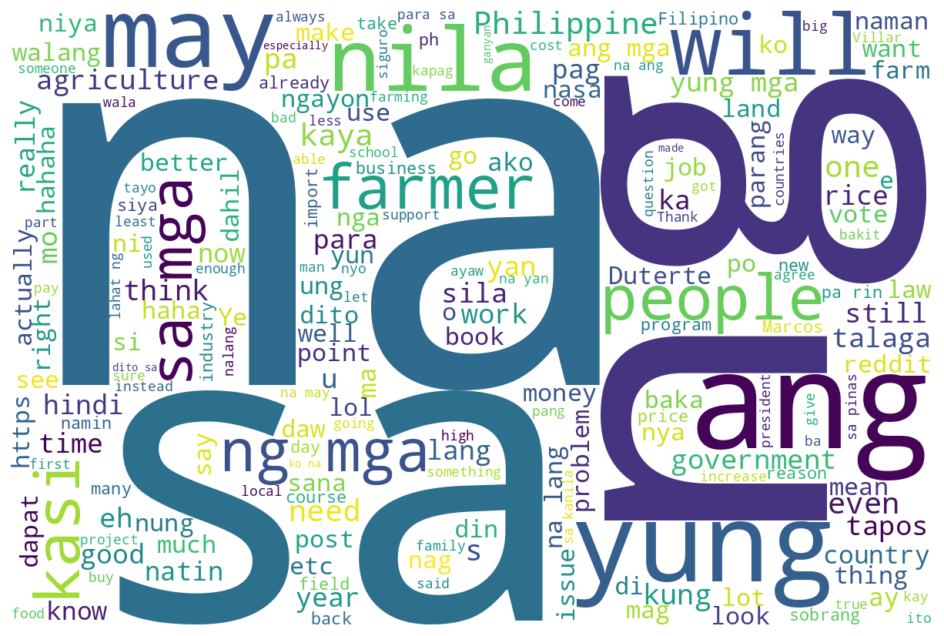

In [ ]:
# Combine the text from 'comment' and 'post_body'
text_data = reddit_raw['comment'].fillna('')

# Join all rows into one string
all_text = " ".join(text_data.astype(str))

# Create WordCloud
wordcloud = WordCloud(
    width=1200,
    height=800,
    background_color="white",
    stopwords=stopwords,
    collocations=True
).generate(all_text)

# Plot the WordCloud
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


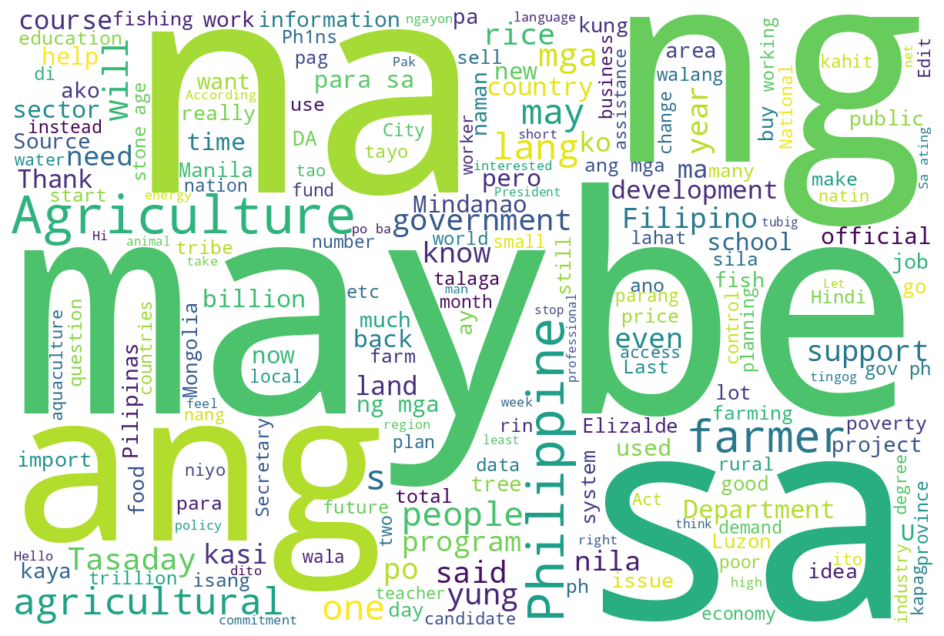

In [ ]:
# Combine the text from 'comment' and 'post_body'
text_data = reddit_raw['post_body'].fillna('')

# Join all rows into one string
all_text = " ".join(text_data.astype(str))

# Define stopwords (optional: add more custom ones)
stopwords = set(STOPWORDS)
stopwords.update(["https", "http", "www", "com", "link", "image", "text", "link", "post"])  # extend stopwords

# Create WordCloud
wordcloud = WordCloud(
    width=1200,
    height=800,
    background_color="white",
    stopwords=stopwords,
    collocations=True
).generate(all_text)

# Plot the WordCloud
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


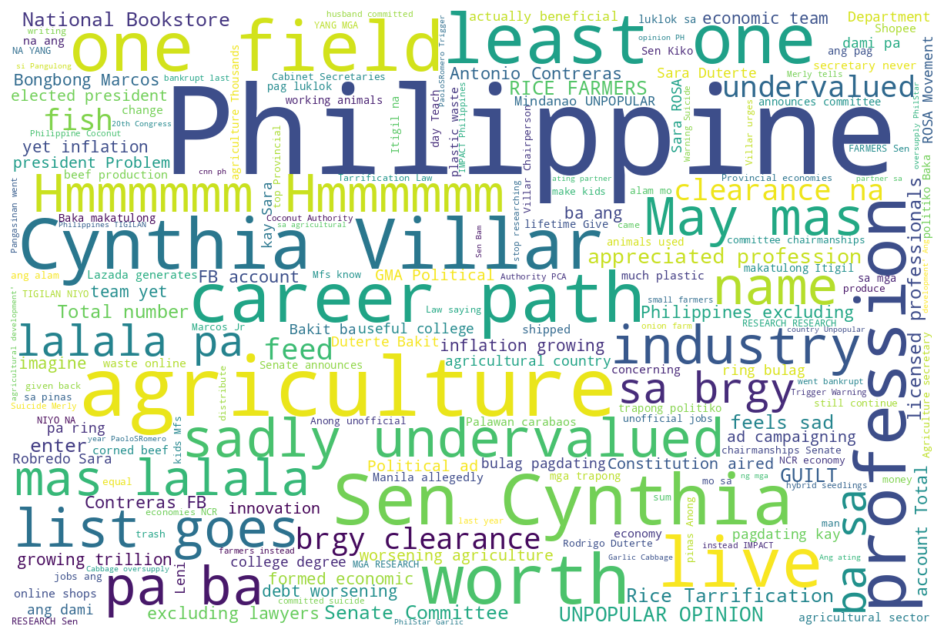

In [ ]:
# Combine the text from 'comment' and 'post_body'
text_data = reddit_raw['post_title'].fillna('')

# Join all rows into one string
all_text = " ".join(text_data.astype(str))

# Define stopwords (optional: add more custom ones)
stopwords = set(STOPWORDS)
stopwords.update(["https", "http", "www", "com", "link", "image", "text", "link", "post"])  # extend stopwords

# Create WordCloud
wordcloud = WordCloud(
    width=1200,
    height=800,
    background_color="white",
    stopwords=stopwords,
    collocations=True
).generate(all_text)

# Plot the WordCloud
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


# **V. Data Preprocessing**

The author aims to **clean** the dataset after understanding the data previously in the EDA section.

During this stage, various data manipulation techniques are performed such as but not limited to:
- Removing NaN values
- Removing deleted comments / authors
- Removing 'non-word' data *(i.e., "asdnasndjasdnasndjasndjasn")*

These are performed to hopefully clean the data for better analysis through social computing methods

In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from collections import Counter

# Download stopwords
nltk.download("stopwords")

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/reddit_truephilippines1000.csv")

# Combine all text columns (title + body + comment)
df["all_text"] = (
    df["post_title"].fillna("") + " " +
    df["post_body"].fillna("") + " " +
    df["comment"].fillna("")
)

# --- Build frequency-based stopwords ---
all_tokens = re.findall(r"[a-z]+", " ".join(df["all_text"].astype(str).str.lower()))

word_counts = Counter(all_tokens)

# Take top 50 most frequent words as custom stopwords (tune N as needed)
FREQ_STOPWORDS = [w for w, _ in word_counts.most_common(50)]

# Merge with NLTK English stopwords
CUSTOM_STOPWORDS = set(stopwords.words("english") + FREQ_STOPWORDS)

print("Sample custom stopwords:", list(CUSTOM_STOPWORDS)[:20])


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Sample custom stopwords: ['if', 'after', 'our', 'o', "we'd", 'yung', "that'll", "hasn't", 'whom', 'mustn', 'yourself', "weren't", 'y', "they've", "didn't", 'he', 'out', 've', 'more', 'your']


In [ ]:
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)  # remove links
    text = re.sub(r"[^a-z\s]", "", text)  # keep only letters
    tokens = [w for w in text.split() if w not in CUSTOM_STOPWORDS and len(w) > 2]
    return " ".join(tokens)

df["clean_text"] = df["all_text"].apply(preprocess)

# Drop empty rows
df = df[df["clean_text"].str.strip() != ""]

print("Number of documents after cleaning:", len(df))
df[["all_text", "clean_text"]].tail(10)


Number of documents after cleaning: 13244


,all_text,clean_text
13234,20 rice kilo price goal for rice a fulfilled p...,kilo price goal fulfilled promise pbbm step ri...
13235,20 rice kilo price goal for rice a fulfilled p...,kilo price goal fulfilled promise pbbm nope st...
13236,20 rice kilo price goal for rice a fulfilled p...,kilo price goal fulfilled promise pbbm definit...
13237,20 rice kilo price goal for rice a fulfilled p...,kilo price goal fulfilled promise pbbm local i...
13238,20 rice kilo price goal for rice a fulfilled p...,kilo price goal fulfilled promise pbbm pero il...
13239,20 rice kilo price goal for rice a fulfilled p...,kilo price goal fulfilled promise pbbm market ...
13240,20 rice kilo price goal for rice a fulfilled p...,kilo price goal fulfilled promise pbbm local i...
13241,20 rice kilo price goal for rice a fulfilled p...,kilo price goal fulfilled promise pbbm alam ku...
13242,20 rice kilo price goal for rice a fulfilled p...,kilo price goal fulfilled promise pbbm corrupt...
13243,20 rice kilo price goal for rice a fulfilled p...,kilo price goal fulfilled promise pbbm low val...


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Vectorize using preprocessed text
vectorizer = CountVectorizer()
dtm = vectorizer.fit_transform(df["clean_text"])

# Fit LDA model
lda = LatentDirichletAllocation(n_components=5, random_state=42)  # adjust n_components
lda.fit(dtm)

# Display topics
def display_topics(model, feature_names, no_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]
        print(f"Topic {topic_idx+1}: {' | '.join(top_words)}")

display_topics(lda, vectorizer.get_feature_names_out(), 10)

# Assign most probable topic t


Topic 1: thats | industry | land | career | whats | worth | live | villar | path | cynthia
Topic 2: mas | clearance | yan | ako | nila | brgy | president | problem | lalala | hmmmmmm
Topic 3: like | country | fish | number | feed | would | professionals | give | licensed | total
Topic 4: one | field | least | profession | name | sadly | list | undervalued | goes | senate
Topic 5: secretary | duterte | sen | leni | mindanao | sara | kay | economy | bakit | kiko


# **VI. Topic Modelling**

This section of this notebook

In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from collections import Counter

# Download stopwords
nltk.download("stopwords")

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/reddit_truephilippines1000.csv")

# Keep only titles (drop nulls)
df = df[["post_title","post_body","comment"]].dropna()

# --- Build frequency-based stopwords ---
all_titles = " ".join(df["post_title"].astype(str).str.lower())
all_tokens = re.findall(r"[a-z]+", all_titles)

word_counts = Counter(all_tokens)

# Take top 50 most frequent words as custom stopwords (tune N)
FREQ_STOPWORDS = [w for w, _ in word_counts.most_common(50)]

# Merge with NLTK English stopwords
CUSTOM_STOPWORDS = set(stopwords.words("english") + FREQ_STOPWORDS)

print("Sample custom stopwords:", list(CUSTOM_STOPWORDS)[:20])


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Sample custom stopwords: ['if', 'after', 'our', 'o', "we'd", "that'll", "hasn't", 'whom', 'mustn', 'yourself', "weren't", 'y', "they've", "didn't", 'he', 'out', 've', 'more', 'your', 'sen']


In [ ]:
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)  # remove links
    text = re.sub(r"[^a-z\s]", "", text)  # keep only letters
    tokens = [w for w in text.split() if w not in CUSTOM_STOPWORDS and len(w) > 2]
    return " ".join(tokens)

df["clean_title"] = df["post_title"].apply(preprocess)

# Drop empty rows
df = df[df["clean_title"].str.strip() != ""]

print("Number of titles after cleaning:", len(df))
df[["post_title", "clean_title"]].head(10)


Number of titles after cleaning: 13233


,post_title,clean_title
0,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",marcoleta hold blue ribbon bam education kiko
1,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",marcoleta hold blue ribbon bam education kiko
2,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",marcoleta hold blue ribbon bam education kiko
3,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",marcoleta hold blue ribbon bam education kiko
4,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",marcoleta hold blue ribbon bam education kiko
5,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",marcoleta hold blue ribbon bam education kiko
6,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",marcoleta hold blue ribbon bam education kiko
7,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",marcoleta hold blue ribbon bam education kiko
8,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",marcoleta hold blue ribbon bam education kiko
9,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",marcoleta hold blue ribbon bam education kiko


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Vectorize using preprocessed titles
vectorizer = CountVectorizer()
dtm = vectorizer.fit_transform(df["clean_title"])

# Fit LDA model
lda = LatentDirichletAllocation(n_components=5, random_state=42)  # change topics as needed
lda.fit(dtm)

# Display topics
def display_topics(model, feature_names, no_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]
        print(f"Topic {topic_idx+1}: {' | '.join(top_words)}")

display_topics(lda, vectorizer.get_feature_names_out(), 10)

# Assign most probable topic to each title
topic_results = lda.transform(dtm)
df["Dominant_Topic"] = topic_results.argmax(axis=1) + 1

# Save results
output_path = "/content/drive/MyDrive/reddit_title_topics_customstop.csv"
df.to_csv(output_path, index=False)
print(f"Saved topic-labeled titles to {output_path}")


Topic 1: bakit | national | bookstore | enter | else | sad | feels | duterte | innovation | imagine
Topic 2: whats | worth | career | path | live | thats | industry | undervaluedunderappreciated | suicide | economic
Topic 3: mas | clearance | lalala | brgy | land | number | account | antonio | excluding | contrerass
Topic 4: least | field | sadly | name | list | hmmmmmm | economy | mga | guilt | tarrification
Topic 5: fish | feed | opinion | unpopular | mindanao | gma | man | change | political | aired
Saved topic-labeled titles to /content/drive/MyDrive/reddit_title_topics_customstop.csv
